In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor 
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

# Styling for report-ready plots
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

In [2]:
# Load Data
df = pd.read_csv('datasets/MODEL_READY_DATASET4.csv')

# Quick inspection
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (58025, 17)


,postcode,price,temp_max,temp_min,rainfall,oil_price,tgp_sydney,aud_usd,retail_margin,price_change_24h,post_avg,post_roll_7,day_sin,day_cos,is_hike_day,margin_hike_interaction,target_next_day_price
0,2518,197.9,15.8,2.3,0.0,66.67,160.2,0.6488,37.7,-10.0,197.9,196.200000,0.433884,-0.900969,0,0.0,195.9
1,2518,187.9,22.4,6.7,0.0,64.09,162.1,0.6498,25.8,28.0,187.9,181.071429,0.781831,0.623490,1,25.8,159.7
2,2518,187.9,19.8,4.5,0.0,63.48,162.7,0.6417,25.2,28.2,186.7,182.557143,-0.433884,-0.900969,0,0.0,169.9
3,2518,197.9,21.5,8.1,0.0,64.21,165.3,0.6538,32.6,30.0,197.9,182.822449,-0.433884,-0.900969,0,0.0,159.9
4,2518,187.9,26.3,8.3,0.0,63.77,164.7,0.6525,23.2,24.0,187.9,185.650000,0.433884,-0.900969,0,0.0,175.9


In [3]:
# Split the data (80% for training, 20% for testing)
split_idx = int(len(df) * 0.8)
train, test = df.iloc[:split_idx], df.iloc[split_idx:]

X_train = train.drop(columns=['target_next_day_price'])
y_train = train['target_next_day_price']
X_test = test.drop(columns=['target_next_day_price'])
y_test = test['target_next_day_price']

print(f"Training on: {len(X_train)} samples")
print(f"Testing on: {len(X_test)} samples")

Training on: 46420 samples
Testing on: 11605 samples


In [4]:
# 1. XGBoost (Tuned for stability)
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# 2. Random Forest (Robust Baseline)
rf = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1)

print("Training Models... (This may take a minute)")
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
print("Training Complete.")

Training Models... (This may take a minute)
Training Complete.


In [5]:
def get_metrics(model, name):
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"--- {name} Results ---")
    print(f"MAE: {mae:.4f} cents")
    print(f"R2 Score: {r2:.4f}\n")
    return preds

rf_preds = get_metrics(rf, "Random Forest")
xgb_preds = get_metrics(xgb, "XGBoost")

--- Random Forest Results ---
MAE: 2.3772 cents
R2 Score: 0.8626

--- XGBoost Results ---
MAE: 2.6904 cents
R2 Score: 0.8615



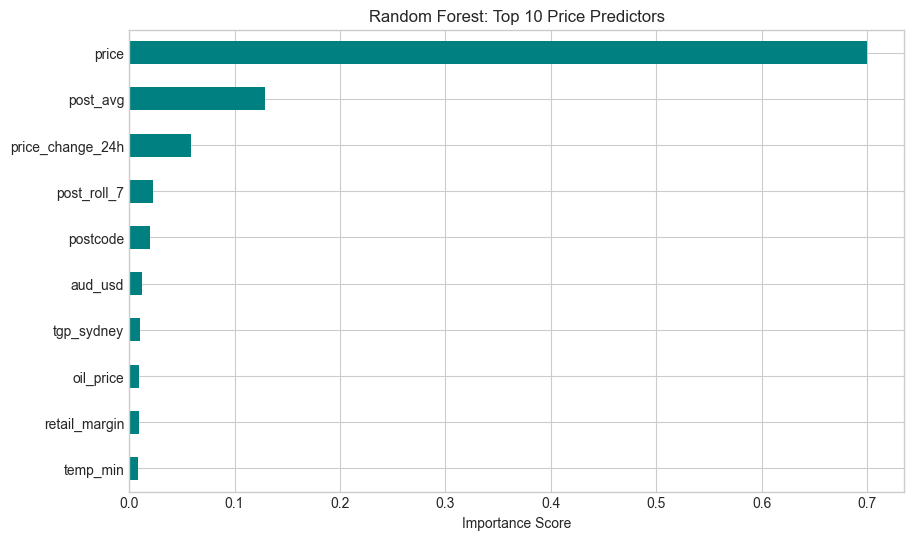

In [6]:
# Focus on the winning model (Random Forest)
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title("Random Forest: Top 10 Price Predictors")
plt.xlabel("Importance Score")
plt.show()

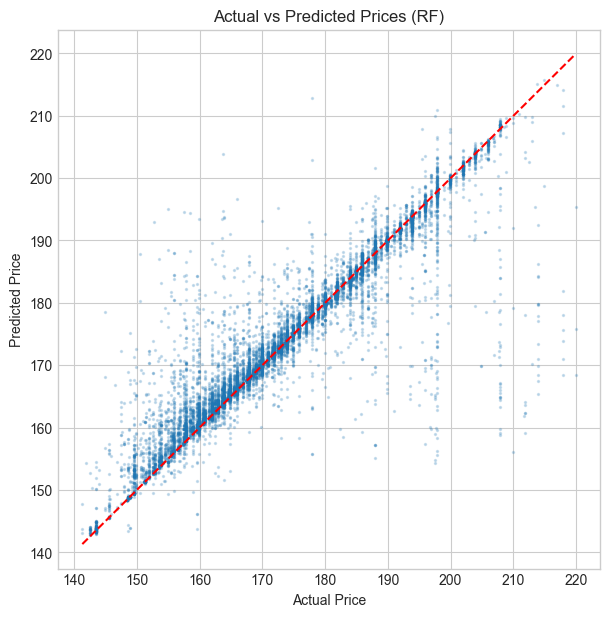

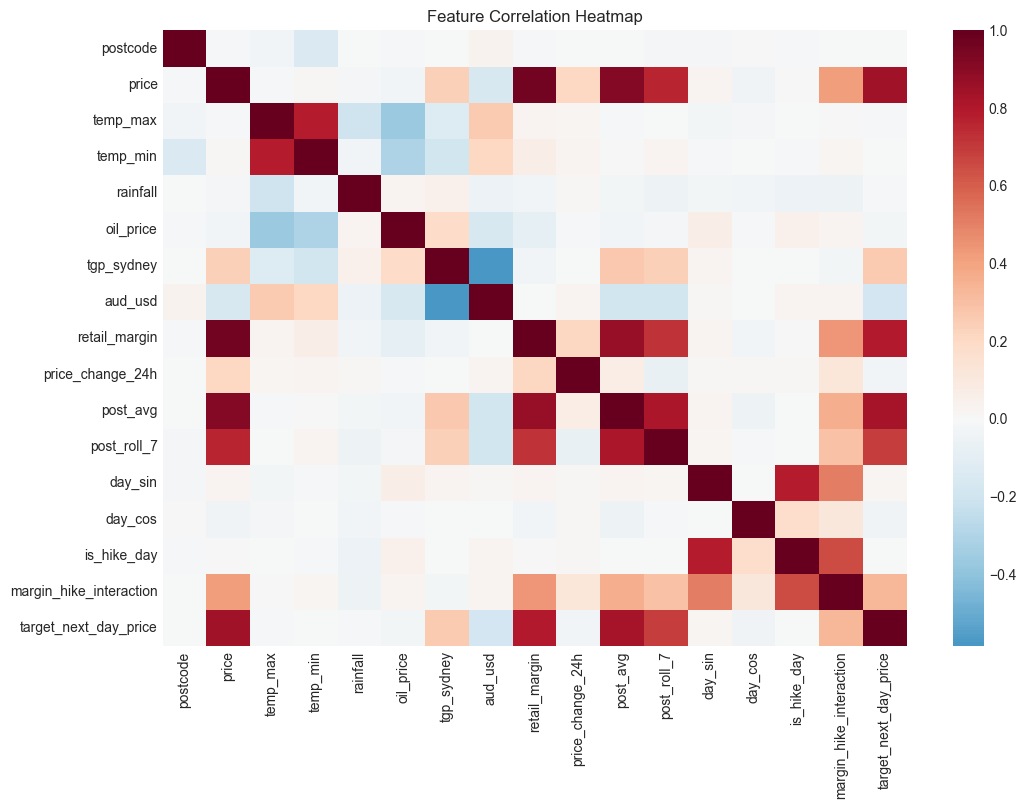

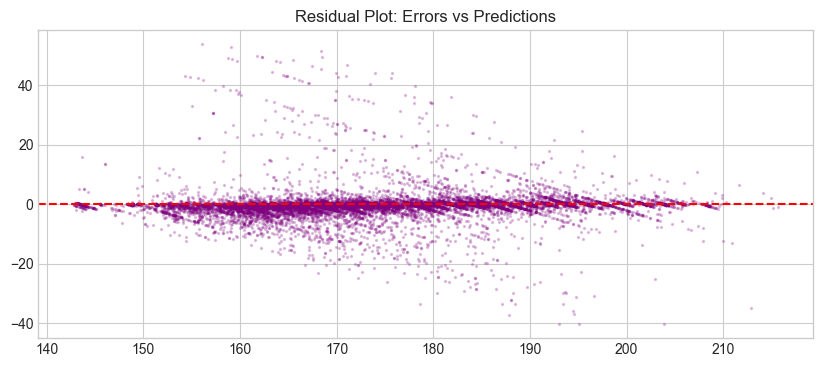

In [7]:
# 1. Actual vs Predicted Scatter
plt.figure(figsize=(7, 7))
plt.scatter(y_test, rf_preds, alpha=0.2, s=2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Actual vs Predicted Prices (RF)")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), cmap='RdBu_r', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

# 3. Residual Plot (Error Analysis)
plt.figure(figsize=(10, 4))
residuals = y_test - rf_preds
plt.scatter(rf_preds, residuals, alpha=0.2, s=2, color='purple')
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot: Errors vs Predictions")
plt.show()